**B. KARAKTERISTIK DATA**

---



In [ ]:
import pandas as pd

df = pd.read_csv("StudentPerformanceFactors.csv")

In [ ]:
print(df.head(5))

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|

In [ ]:
df.describe().show()

+-------+------------------+------------------+--------------------+-------------------+--------------------------+------------------+------------------+----------------+---------------+------------------+-------------+---------------+-----------+--------------+------------------+---------------------+------------------------+------------------+------+------------------+
|summary|     Hours_Studied|        Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|       Sleep_Hours|   Previous_Scores|Motivation_Level|Internet_Access| Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence| Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|        Exam_Score|
+-------+------------------+------------------+--------------------+-------------------+--------------------------+------------------+------------------+----------------+---------------+------------------+-------------+---------------+-----------+-----

In [ ]:
df.dtypes

[('Hours_Studied', 'int'),
 ('Attendance', 'int'),
 ('Parental_Involvement', 'string'),
 ('Access_to_Resources', 'string'),
 ('Extracurricular_Activities', 'string'),
 ('Sleep_Hours', 'int'),
 ('Previous_Scores', 'int'),
 ('Motivation_Level', 'string'),
 ('Internet_Access', 'string'),
 ('Tutoring_Sessions', 'int'),
 ('Family_Income', 'string'),
 ('Teacher_Quality', 'string'),
 ('School_Type', 'string'),
 ('Peer_Influence', 'string'),
 ('Physical_Activity', 'int'),
 ('Learning_Disabilities', 'string'),
 ('Parental_Education_Level', 'string'),
 ('Distance_from_Home', 'string'),
 ('Gender', 'string'),
 ('Exam_Score', 'int')]

In [ ]:
df_count = df.count()

**C. PREPROCESSING DATA**

---



1\. Data Cleaning

a. Membersihkan Nilai Null

In [ ]:
from pyspark.sql.functions import col

col_null = [col_name for col_name in df.columns if df.filter(col(col_name).isNull()).count() > 0]

print(f"Fitur yang memiliki nilai NULL: {col_null}")

Fitur yang memiliki nilai NULL: ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']


In [ ]:
from pyspark.sql.functions import col, skewness

for column in col_null:
  nulls_count = df.filter((col(column).isNull())).count()

  print("=========================")
  print(f"Jumlah Null di kolom {column}: {nulls_count}")
  print(f"Persentase Null di kolom {column}: {nulls_count/df_count*100}")
  print(f"Nilai unik di kolom {column}:")
  df.select(column).distinct().show()
  print("=========================")

Jumlah Null di kolom Teacher_Quality: 78
Persentase Null di kolom Teacher_Quality: 1.1805660662933253
Nilai unik di kolom Teacher_Quality:
+---------------+
|Teacher_Quality|
+---------------+
|           High|
|            Low|
|         Medium|
|           NULL|
+---------------+

Jumlah Null di kolom Parental_Education_Level: 90
Persentase Null di kolom Parental_Education_Level: 1.362191614953837
Nilai unik di kolom Parental_Education_Level:
+------------------------+
|Parental_Education_Level|
+------------------------+
|             High School|
|            Postgraduate|
|                 College|
|                    NULL|
+------------------------+

Jumlah Null di kolom Distance_from_Home: 67
Persentase Null di kolom Distance_from_Home: 1.0140759800211896
Nilai unik di kolom Distance_from_Home:
+------------------+
|Distance_from_Home|
+------------------+
|               Far|
|              Near|
|          Moderate|
|              NULL|
+------------------+



In [ ]:
df_2 = df

In [ ]:
from pyspark.sql.functions import when

df_2 = df_2.withColumn(
    "Teacher_Quality_Index",
    when(df_2["Teacher_Quality"] == "Low", 1)
    .when(df_2["Teacher_Quality"] == "Medium", 2)
    .when(df_2["Teacher_Quality"] == "High", 3)
)
df_2 = df_2.withColumn(
    "Parental_Education_Level_Index",
    when(df_2["Parental_Education_Level"] == "High School", 1)
    .when(df_2["Parental_Education_Level"] == "College", 2)
    .when(df_2["Parental_Education_Level"] == "Post Graduate", 3)
)
df_2 = df_2.withColumn(
    "Distance_from_Home_Index",
    when(df_2["Distance_from_Home"] == "Near", 1)
    .when(df_2["Distance_from_Home"] == "Moderate", 2)
    .when(df_2["Distance_from_Home"] == "Far", 3)
)
df_2.show(5, truncate=False)

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+---------------------+------------------------------+------------------------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|Teacher_Quality_Index|Parental_Education_Level_Index|Distance_from_Home_Index|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-----

In [ ]:
df_2 = df_2.drop("Teacher_Quality", "Parental_Education_Level", "Distance_from_Home")

In [ ]:
col_null_2 = [col_name for col_name in df_2.columns if df_2.filter(col(col_name).isNull()).count() > 0]

print(f"Fitur yang memiliki nilai NULL: {col_null_2}")

Fitur yang memiliki nilai NULL: ['Teacher_Quality_Index', 'Parental_Education_Level_Index', 'Distance_from_Home_Index']


In [ ]:
for column in col_null_2:
  skew_value = df_2.select(skewness(col(column))).collect()[0][0]
  print(f"Nilai skewness di kolom {column}: {skew_value}")

Nilai skewness di kolom Teacher_Quality_Index: -0.10842373834930924
Nilai skewness di kolom Parental_Education_Level_Index: 0.48737990097504236
Nilai skewness di kolom Distance_from_Home_Index: 0.9714735229250361


In [ ]:
#TQIndex

In [ ]:
from pyspark.sql.functions import col, percentile_approx

Q2_tqIndex = df_2.select(percentile_approx("Teacher_Quality_Index", 0.5)).first()[0]

print(f"Teacher_Quality Median: {Q2_tqIndex}")

Teacher_Quality Median: 2


In [ ]:
df_2 = df_2.fillna({"Teacher_Quality_Index": Q2_tqIndex})

In [ ]:
#PELIndex

In [ ]:
from pyspark.sql.functions import col

mode_pelIndex = df_2.groupBy('Parental_Education_Level_Index').count()
mode_pelIndex = mode_pelIndex.orderBy(col('count').desc()).first()
mode_pelIndex_value = mode_pelIndex['Parental_Education_Level_Index']

print(f"Modus kolom Parental_Education_Level_Index: {mode_pelIndex_value}")

Modus kolom Parental_Education_Level_Index: 1


In [ ]:
df_2 = df_2.fillna({"Parental_Education_Level_Index": mode_pelIndex_value})

In [ ]:
#DFHIndex

In [ ]:
from pyspark.sql.functions import col

mode_dfhIndex = df_2.groupBy('Distance_from_Home_Index').count()
mode_dfhIndex = mode_dfhIndex.orderBy(col('count').desc()).first()
mode_dfhIndex_value = mode_dfhIndex['Distance_from_Home_Index']

print(f"Modus kolom Distance_from_Home_Index: {mode_dfhIndex_value}")

Modus kolom Distance_from_Home_Index: 1


In [ ]:
df_2 = df_2.fillna({"Distance_from_Home_Index": mode_dfhIndex_value})

In [ ]:
print([col_name for col_name in df_2.columns if df_2.filter(col(col_name).isNull()).count() > 0])

[]


b. Membersihkan Nilai Duplikat

In [ ]:
df_2.groupBy(df_2.columns).count().filter("count > 1").show()

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+-----------+--------------+-----------------+---------------------+------+----------+---------------------+------------------------------+------------------------+-----+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Gender|Exam_Score|Teacher_Quality_Index|Parental_Education_Level_Index|Distance_from_Home_Index|count|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+-----------+--------------+-----------------+---------------------+------+----------+--------------

c. Membersihkan Nilai Outlier

In [ ]:
df_2.dtypes

[('Hours_Studied', 'int'),
 ('Attendance', 'int'),
 ('Parental_Involvement', 'string'),
 ('Access_to_Resources', 'string'),
 ('Extracurricular_Activities', 'string'),
 ('Sleep_Hours', 'int'),
 ('Previous_Scores', 'int'),
 ('Motivation_Level', 'string'),
 ('Internet_Access', 'string'),
 ('Tutoring_Sessions', 'int'),
 ('Family_Income', 'string'),
 ('School_Type', 'string'),
 ('Peer_Influence', 'string'),
 ('Physical_Activity', 'int'),
 ('Learning_Disabilities', 'string'),
 ('Gender', 'string'),
 ('Exam_Score', 'int'),
 ('Teacher_Quality_Index', 'int'),
 ('Parental_Education_Level_Index', 'int'),
 ('Distance_from_Home_Index', 'int')]

In [ ]:
from pyspark.sql.functions import col

numerical_col = [col_name for col_name, dtype in df_2.dtypes if dtype in ('int')]
categorical_col = [col_name for col_name, dtype in df_2.dtypes if dtype in ('string')]

print(f"Fitur Numerik: {numerical_col}")
print(f"Fitur Kategorikal: {categorical_col}")

Fitur Numerik: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score', 'Teacher_Quality_Index', 'Parental_Education_Level_Index', 'Distance_from_Home_Index']
Fitur Kategorikal: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Gender']


In [ ]:
for column in categorical_col:
  df_2.select(column).distinct().show()

+--------------------+
|Parental_Involvement|
+--------------------+
|                High|
|                 Low|
|              Medium|
+--------------------+

+-------------------+
|Access_to_Resources|
+-------------------+
|               High|
|                Low|
|             Medium|
+-------------------+

+--------------------------+
|Extracurricular_Activities|
+--------------------------+
|                        No|
|                       Yes|
+--------------------------+

+----------------+
|Motivation_Level|
+----------------+
|            High|
|             Low|
|          Medium|
+----------------+

+---------------+
|Internet_Access|
+---------------+
|             No|
|            Yes|
+---------------+

+-------------+
|Family_Income|
+-------------+
|         High|
|          Low|
|       Medium|
+-------------+

+-----------+
|School_Type|
+-----------+
|     Public|
|    Private|
+-----------+

+--------------+
|Peer_Influence|
+--------------+
|      Positive|

In [ ]:
for column in numerical_col:
    Q1, Q3 = df_2.approxQuantile(column, [0.25, 0.75], 0.01)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_2.filter((col(column) < lower_bound) | (col(column) > upper_bound))
    outliers_count = outliers.count()

    print(f"Outliers di kolom {column}")
    outliers.select(column).show(5)
    print(f"Jumlah: {outliers_count}")
    print(f"Persentase: {outliers_count/df_count*100}")
    print("=========================")

Outliers di kolom Hours_Studied
+-------------+
|Hours_Studied|
+-------------+
|           43|
|            1|
|           38|
|            3|
|            3|
+-------------+
only showing top 5 rows

Jumlah: 43
Persentase: 0.6508248827001665
Outliers di kolom Attendance
+----------+
|Attendance|
+----------+
+----------+

Jumlah: 0
Persentase: 0.0
Outliers di kolom Sleep_Hours
+-----------+
|Sleep_Hours|
+-----------+
+-----------+

Jumlah: 0
Persentase: 0.0
Outliers di kolom Previous_Scores
+---------------+
|Previous_Scores|
+---------------+
+---------------+

Jumlah: 0
Persentase: 0.0
Outliers di kolom Tutoring_Sessions
+-----------------+
|Tutoring_Sessions|
+-----------------+
|                4|
|                4|
|                5|
|                4|
|                4|
+-----------------+
only showing top 5 rows

Jumlah: 430
Persentase: 6.508248827001665
Outliers di kolom Physical_Activity
+-----------------+
|Physical_Activity|
+-----------------+
+-----------------+

Jum

In [ ]:
df_3 = df_2

In [ ]:
#Hours_Studied
Q1_hs = df.approxQuantile("Hours_Studied", [0.25], 0.01)[0]
Q3_hs = df.approxQuantile("Hours_Studied", [0.75], 0.01)[0]
IQR_hs = Q3_hs - Q1_hs
lower_bound_hs = Q1_hs - 1.5 * IQR_hs
upper_bound_hs = Q3_hs + 1.5 * IQR_hs

df_3 = df_3.filter((col("Hours_Studied") >= lower_bound_hs) & (col("Hours_Studied") <= upper_bound_hs))

In [ ]:
df_3.count()

6564

In [ ]:
df_3.filter((col("Hours_Studied") < lower_bound_hs) | (col("Hours_Studied") > upper_bound_hs)).count()

0

In [ ]:
outlier_col = ['Hours_Studied', 'Tutoring_Sessions', 'Exam_Score']

for column in outlier_col:
    Q1, Q3 = df_3.approxQuantile(column, [0.25, 0.75], 0.01)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_3.filter((col(column) < lower_bound) | (col(column) > upper_bound))
    outliers_count = outliers.count()

    print(f"Outliers di kolom {column} setelah drop baris outlier pada Hours_Studied")
    outliers.select(column).show(5)
    print(f"Jumlah: {outliers_count}")
    print(f"Persentase: {outliers_count/df_count*100}")
    print("=========================")

Outliers di kolom Hours_Studied setelah drop baris outlier pada Hours_Studied
+-------------+
|Hours_Studied|
+-------------+
+-------------+

Jumlah: 0
Persentase: 0.0
Outliers di kolom Tutoring_Sessions setelah drop baris outlier pada Hours_Studied
+-----------------+
|Tutoring_Sessions|
+-----------------+
|                4|
|                4|
|                5|
|                4|
|                4|
+-----------------+
only showing top 5 rows

Jumlah: 430
Persentase: 6.508248827001665
Outliers di kolom Exam_Score setelah drop baris outlier pada Hours_Studied
+----------+
|Exam_Score|
+----------+
|       100|
|        76|
|        79|
|        89|
|        86|
+----------+
only showing top 5 rows

Jumlah: 91
Persentase: 1.3773270773422128


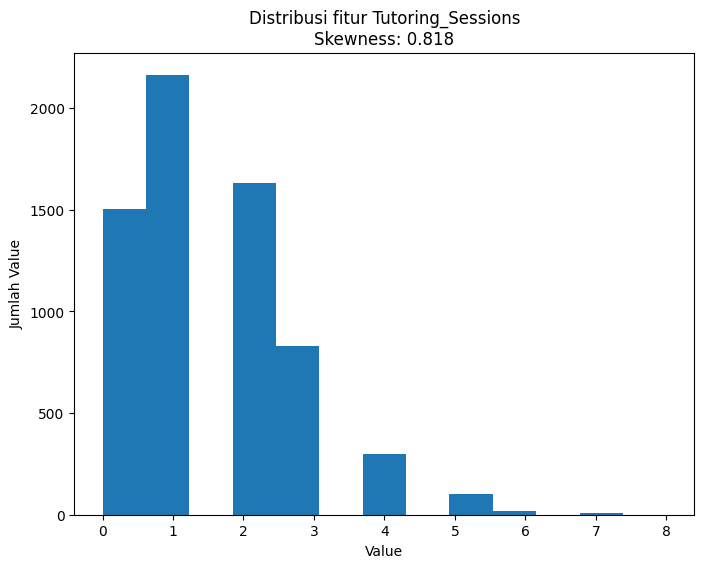

In [ ]:
#Tutoring_Sessions
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import col, skewness

ts = df_3.select("Tutoring_Sessions").toPandas()["Tutoring_Sessions"]
ts_skewness = df_3.select(skewness(col("Tutoring_Sessions"))).collect()[0][0]
sturges_bin_ts = int(1 + np.log2(len(ts)))

plt.figure(figsize=(8, 6))
plt.hist(ts, bins=sturges_bin_ts)
plt.title(f"Distribusi fitur Tutoring_Sessions\nSkewness: {ts_skewness:.3f}")
plt.xlabel("Value")
plt.ylabel("Jumlah Value")
plt.show()

In [ ]:
Q1_ts = df_3.approxQuantile("Tutoring_Sessions", [0.25], 0.01)[0]
Q2_ts = df_3.approxQuantile("Tutoring_Sessions", [0.5], 0.01)[0]
Q3_ts = df_3.approxQuantile("Tutoring_Sessions", [0.75], 0.01)[0]
IQR_ts = Q3_ts - Q1_ts
lower_bound_ts = Q1_ts - 1.5 * IQR_ts
upper_bound_ts = Q3_ts + 2.0 * IQR_ts

In [ ]:
print(f'Median kolom Tutoring_Sessions: {Q2_ts}')

Median kolom Tutoring_Sessions: 1.0


In [ ]:
df_3.filter((col("Tutoring_Sessions") < lower_bound_ts) | (col("Tutoring_Sessions") > upper_bound_ts)).count()

129

In [ ]:
df_3 = df_3.withColumn("Tutoring_Sessions_Imputed", when((col("Tutoring_Sessions") < lower_bound_ts) | (col("Tutoring_Sessions") > upper_bound_ts), Q2_ts).otherwise(col("Tutoring_Sessions")))

In [ ]:
df_3.filter((col("Tutoring_Sessions_Imputed") < lower_bound_ts) | (col("Tutoring_Sessions_Imputed") > upper_bound_ts)).count()

0

In [ ]:
df_3 = df_3.drop("Tutoring_Sessions")

In [ ]:
#Exam_Score
df_3.filter((col("Exam_Score") > 100)).count()

1

In [ ]:
df_3 = df_3.filter((col("Exam_Score") <= 100))

df_3.count()

6563

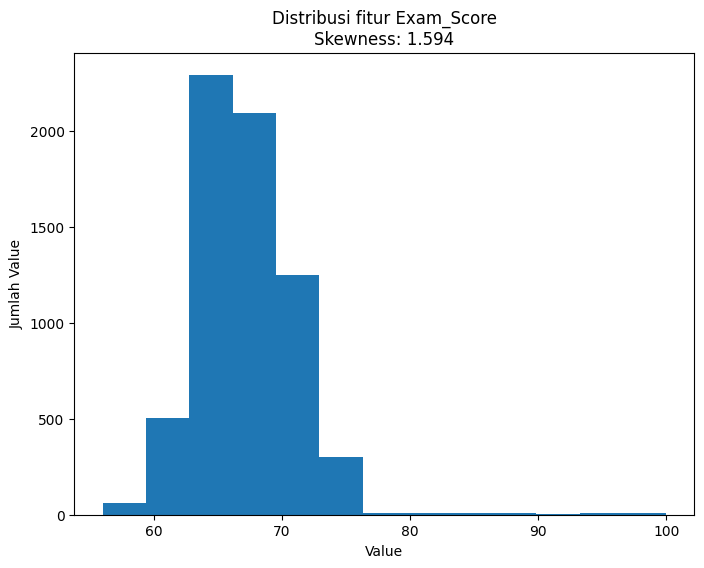

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, skewness

es = df_3.select("Exam_Score").toPandas()["Exam_Score"]
es_skewness = df_3.select(skewness(col("Exam_Score"))).collect()[0][0]
sturges_bin_es = int(1 + np.log2(len(es)))

plt.figure(figsize=(8, 6))
plt.hist(es, bins=sturges_bin_es)
plt.title(f"Distribusi fitur Exam_Score\nSkewness: {es_skewness:.3f}")
plt.xlabel("Value")
plt.ylabel("Jumlah Value")
plt.show()

In [ ]:
Q1_es = df_3.approxQuantile("Exam_Score", [0.25], 0.01)[0]
Q2_es = df_3.approxQuantile("Exam_Score", [0.5], 0.01)[0]
Q3_es = df_3.approxQuantile("Exam_Score", [0.75], 0.01)[0]
IQR_es = Q3_es - Q1_es
lower_bound_es = Q1_es - 1.5 * IQR_es
upper_bound_es = Q3_es + 2.5 * IQR_es

In [ ]:
print(f'Median kolom Exam_Score: {Q2_es}')

Median kolom Exam_Score: 67.0


In [ ]:
df_3.filter((col("Exam_Score") < lower_bound_es) | (col("Exam_Score") > upper_bound_es)).count()

68

In [ ]:
df_3 = df_3.withColumn("Exam_Score_Imputed", when((col("Exam_Score") < lower_bound_es) | (col("Exam_Score") > upper_bound_es), Q2_es).otherwise(col("Exam_Score")))

In [ ]:
df_3.filter((col("Exam_Score_Imputed") < lower_bound_es) | (col("Exam_Score_Imputed") > upper_bound_es)).count()

0

In [ ]:
df_3 = df_3.drop("Exam_Score")

2\. Data Transformation

In [ ]:
feature_col = df_3.drop('Exam_Score_Imputed')
label_col = df_3.select('Exam_Score_Imputed')

In [ ]:
feature_col.show(5)

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-------------+-----------+--------------+-----------------+---------------------+------+---------------------+------------------------------+------------------------+-------------------------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Family_Income|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Gender|Teacher_Quality_Index|Parental_Education_Level_Index|Distance_from_Home_Index|Tutoring_Sessions_Imputed|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-------------+-----------+--------------+-----------------+---------------------+------+---------------------+------------------------------+--------

In [ ]:
processed_feature_list = ['Teacher_Quality_Index', 'Parental_Education_Level_Index', 'Distance_from_Home_Index']

numerical_feature = feature_col.select(
    [col_name for col_name, dtype in feature_col.dtypes if dtype in ('int', 'double') and col_name not in processed_feature_list])
categorical_feature = feature_col.select(
    [col_name for col_name, dtype in feature_col.dtypes if dtype in ('string')])

a. Fitur Numerik

In [ ]:
numerical_feature.show(5)

+-------------+----------+-----------+---------------+-----------------+-------------------------+
|Hours_Studied|Attendance|Sleep_Hours|Previous_Scores|Physical_Activity|Tutoring_Sessions_Imputed|
+-------------+----------+-----------+---------------+-----------------+-------------------------+
|           23|        84|          7|             73|                3|                      0.0|
|           19|        64|          8|             59|                4|                      2.0|
|           24|        98|          7|             91|                4|                      2.0|
|           29|        89|          8|             98|                4|                      1.0|
|           19|        92|          6|             65|                4|                      3.0|
+-------------+----------+-----------+---------------+-----------------+-------------------------+
only showing top 5 rows



In [ ]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

assembler = VectorAssembler(inputCols=feature_num.columns, outputCol="feature_num")
feature_num = assembler.transform(feature_num)

scaler = MinMaxScaler(inputCol="feature_num", outputCol="scaled_feature_num")
scaler_model = scaler.fit(feature_num)
scaled_num = scaler_model.transform(feature_num)

In [ ]:
scaled_num = scaled_num.select("scaled_feature_num")

scaled_num.show(5, truncate=False)

+----------------------------------------------------------------------------+
|scaled_feature_num                                                          |
+----------------------------------------------------------------------------+
|[0.59375,0.6000000000000001,0.5,0.46,0.5,0.0]                               |
|[0.46875,0.1,0.6666666666666666,0.18,0.6666666666666666,0.5]                |
|[0.625,0.9500000000000001,0.5,0.8200000000000001,0.6666666666666666,0.5]    |
|[0.78125,0.7250000000000001,0.6666666666666666,0.96,0.6666666666666666,0.25]|
|[0.46875,0.8,0.3333333333333333,0.3,0.6666666666666666,0.75]                |
+----------------------------------------------------------------------------+
only showing top 5 rows



b. Fitur Nominal

In [ ]:
feature_cat.show(5)

+--------------------+-------------------+--------------------------+----------------+---------------+-------------+-----------+--------------+---------------------+------+
|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Motivation_Level|Internet_Access|Family_Income|School_Type|Peer_Influence|Learning_Disabilities|Gender|
+--------------------+-------------------+--------------------------+----------------+---------------+-------------+-----------+--------------+---------------------+------+
|                 Low|               High|                        No|             Low|            Yes|          Low|     Public|      Positive|                   No|  Male|
|                 Low|             Medium|                        No|             Low|            Yes|       Medium|     Public|      Negative|                   No|Female|
|              Medium|             Medium|                       Yes|          Medium|            Yes|       Medium|     Public|       

In [ ]:
cat_ordinal = feature_cat.select('Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Peer_Influence')
cat_nominal = feature_cat.select('Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Gender')

In [ ]:
#Kategorik Ordinal

In [ ]:
cat_ordinal.show(5)

+--------------------+-------------------+----------------+-------------+--------------+
|Parental_Involvement|Access_to_Resources|Motivation_Level|Family_Income|Peer_Influence|
+--------------------+-------------------+----------------+-------------+--------------+
|                 Low|               High|             Low|          Low|      Positive|
|                 Low|             Medium|             Low|       Medium|      Negative|
|              Medium|             Medium|          Medium|       Medium|       Neutral|
|                 Low|             Medium|          Medium|       Medium|      Negative|
|              Medium|             Medium|          Medium|       Medium|       Neutral|
+--------------------+-------------------+----------------+-------------+--------------+
only showing top 5 rows



In [ ]:
cat_ordinal = cat_ordinal.withColumn(
    "Parental_Involvement_Index",
    when(cat_ordinal["Parental_Involvement"] == "Low", 1)
    .when(cat_ordinal["Parental_Involvement"] == "Medium", 2)
    .when(cat_ordinal["Parental_Involvement"] == "High", 3)
).withColumn(
    "Access_to_Resources_Index",
    when(cat_ordinal["Access_to_Resources"] == "Low", 1)
    .when(cat_ordinal["Access_to_Resources"] == "Medium", 2)
    .when(cat_ordinal["Access_to_Resources"] == "High", 3)
).withColumn(
    "Motivation_Level_Index",
    when(cat_ordinal["Motivation_Level"] == "Low", 1)
    .when(cat_ordinal["Motivation_Level"] == "Medium", 2)
    .when(cat_ordinal["Motivation_Level"] == "High", 3)
).withColumn(
    "Family_Income_Index",
    when(cat_ordinal["Family_Income"] == "Low", 1)
    .when(cat_ordinal["Family_Income"] == "Medium", 2)
    .when(cat_ordinal["Family_Income"] == "High", 3)
).withColumn(
    "Peer_Influence_Index",
    when(cat_ordinal["Peer_Influence"] == "Negative", 1)
    .when(cat_ordinal["Peer_Influence"] == "Neutral", 2)
    .when(cat_ordinal["Peer_Influence"] == "Positive", 3)
)

In [ ]:
ordinal_encoded = cat_ordinal.drop("Parental_Involvement", "Access_to_Resources", "Motivation_Level",  "Family_Income", "Peer_Influence")

In [ ]:
ordinal_encoded.show(5)

+--------------------------+-------------------------+----------------------+-------------------+--------------------+
|Parental_Involvement_Index|Access_to_Resources_Index|Motivation_Level_Index|Family_Income_Index|Peer_Influence_Index|
+--------------------------+-------------------------+----------------------+-------------------+--------------------+
|                         1|                        3|                     1|                  1|                   3|
|                         1|                        2|                     1|                  2|                   1|
|                         2|                        2|                     2|                  2|                   2|
|                         1|                        2|                     2|                  2|                   1|
|                         2|                        2|                     2|                  2|                   2|
+--------------------------+--------------------

In [ ]:
from pyspark.sql.functions import monotonically_increasing_id

processed_feature = feature_col.select(processed_feature_list).withColumn("id", monotonically_increasing_id())

processed_feature.show(5)

+---------------------+------------------------------+------------------------+---+
|Teacher_Quality_Index|Parental_Education_Level_Index|Distance_from_Home_Index| id|
+---------------------+------------------------------+------------------------+---+
|                    2|                             1|                       1|  0|
|                    2|                             2|                       2|  1|
|                    2|                             1|                       1|  2|
|                    2|                             1|                       2|  3|
|                    3|                             2|                       1|  4|
+---------------------+------------------------------+------------------------+---+
only showing top 5 rows



In [ ]:
ordinal_encoded = ordinal_encoded.withColumn("id", monotonically_increasing_id())

ordinal_encoded.show(5)

+--------------------------+-------------------------+----------------------+-------------------+--------------------+---+
|Parental_Involvement_Index|Access_to_Resources_Index|Motivation_Level_Index|Family_Income_Index|Peer_Influence_Index| id|
+--------------------------+-------------------------+----------------------+-------------------+--------------------+---+
|                         1|                        3|                     1|                  1|                   3|  0|
|                         1|                        2|                     1|                  2|                   1|  1|
|                         2|                        2|                     2|                  2|                   2|  2|
|                         1|                        2|                     2|                  2|                   1|  3|
|                         2|                        2|                     2|                  2|                   2|  4|
+---------------

In [ ]:
ordinal_encoded = ordinal_encoded.join(processed_feature, on="id")
ordinal_encoded = ordinal_encoded.drop("id")

ordinal_encoded.show(5)

+--------------------------+-------------------------+----------------------+-------------------+--------------------+---------------------+------------------------------+------------------------+
|Parental_Involvement_Index|Access_to_Resources_Index|Motivation_Level_Index|Family_Income_Index|Peer_Influence_Index|Teacher_Quality_Index|Parental_Education_Level_Index|Distance_from_Home_Index|
+--------------------------+-------------------------+----------------------+-------------------+--------------------+---------------------+------------------------------+------------------------+
|                         1|                        3|                     1|                  1|                   3|                    2|                             1|                       1|
|                         1|                        2|                     1|                  2|                   1|                    2|                             2|                       2|
|              

In [ ]:
#Kategorik Nominal

In [ ]:
cat_nominal.show(5)

+--------------------------+---------------+-----------+--------------+---------------------+------+
|Extracurricular_Activities|Internet_Access|School_Type|Peer_Influence|Learning_Disabilities|Gender|
+--------------------------+---------------+-----------+--------------+---------------------+------+
|                        No|            Yes|     Public|      Positive|                   No|  Male|
|                        No|            Yes|     Public|      Negative|                   No|Female|
|                       Yes|            Yes|     Public|       Neutral|                   No|  Male|
|                       Yes|            Yes|     Public|      Negative|                   No|  Male|
|                       Yes|            Yes|     Public|       Neutral|                   No|Female|
+--------------------------+---------------+-----------+--------------+---------------------+------+
only showing top 5 rows



In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

indexers = []
encoders = []

for col in cat_nominal.columns:
    indexer = StringIndexer(inputCol=col, outputCol=col + "_indexed")
    indexers.append(indexer)

    encoder = OneHotEncoder(inputCol=col + "_indexed", outputCol=col + "_onehot")
    encoders.append(encoder)

pipeline_nominal = Pipeline(stages=indexers + encoders)

model_nominal = pipeline_nominal.fit(cat_nominal)
encoded_nominal = model_nominal.transform(cat_nominal)

In [ ]:
nominal_encoded = encoded_nominal.select("Extracurricular_Activities_onehot", "Internet_Access_onehot", "School_Type_onehot", "Peer_Influence_onehot", "Learning_Disabilities_onehot", "Gender_onehot")

nominal_encoded.show(5)

+---------------------------------+----------------------+------------------+---------------------+----------------------------+-------------+
|Extracurricular_Activities_onehot|Internet_Access_onehot|School_Type_onehot|Peer_Influence_onehot|Learning_Disabilities_onehot|Gender_onehot|
+---------------------------------+----------------------+------------------+---------------------+----------------------------+-------------+
|                        (1,[],[])|         (1,[0],[1.0])|     (1,[0],[1.0])|        (2,[0],[1.0])|               (1,[0],[1.0])|(1,[0],[1.0])|
|                        (1,[],[])|         (1,[0],[1.0])|     (1,[0],[1.0])|            (2,[],[])|               (1,[0],[1.0])|    (1,[],[])|
|                    (1,[0],[1.0])|         (1,[0],[1.0])|     (1,[0],[1.0])|        (2,[1],[1.0])|               (1,[0],[1.0])|(1,[0],[1.0])|
|                    (1,[0],[1.0])|         (1,[0],[1.0])|     (1,[0],[1.0])|            (2,[],[])|               (1,[0],[1.0])|(1,[0],[1.0])|

In [ ]:
from pyspark.sql.functions import monotonically_increasing_id

scaled_num = scaled_num.withColumn("id", monotonically_increasing_id())
nominal_encoded = nominal_encoded.withColumn("id", monotonically_increasing_id())
ordinal_encoded = ordinal_encoded.withColumn("id", monotonically_increasing_id())

merged_dataset = scaled_num.join(nominal_encoded, on="id").join(ordinal_encoded, on="id")

In [ ]:
merged_dataset.show(5)

+----+--------------------+---------------------------------+----------------------+------------------+---------------------+----------------------------+-------------+--------------------------+-------------------------+----------------------+-------------------+--------------------+---------------------+------------------------------+------------------------+
|  id|  scaled_feature_num|Extracurricular_Activities_onehot|Internet_Access_onehot|School_Type_onehot|Peer_Influence_onehot|Learning_Disabilities_onehot|Gender_onehot|Parental_Involvement_Index|Access_to_Resources_Index|Motivation_Level_Index|Family_Income_Index|Peer_Influence_Index|Teacher_Quality_Index|Parental_Education_Level_Index|Distance_from_Home_Index|
+----+--------------------+---------------------------------+----------------------+------------------+---------------------+----------------------------+-------------+--------------------------+-------------------------+----------------------+-------------------+--------

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["scaled_feature_num", "Extracurricular_Activities_onehot", "Internet_Access_onehot", "School_Type_onehot", "Peer_Influence_onehot", "Learning_Disabilities_onehot", "Gender_onehot", "Parental_Involvement_Index", "Access_to_Resources_Index", "Motivation_Level_Index", "Family_Income_Index", "Peer_Influence_Index"],
    outputCol="features"
)

merged_transform = assembler.transform(merged_dataset)

In [ ]:
features = merged_transform.select("id", "features")
features.show(5, truncate=False)

+----+--------------------------------------------------------------------------------------------------------------+
|id  |features                                                                                                      |
+----+--------------------------------------------------------------------------------------------------------------+
|26  |[0.28125,0.775,0.3333333333333333,0.8,0.3333333333333333,0.25,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,3.0,1.0]|
|29  |[0.4375,0.15000000000000002,0.0,0.02,0.3333333333333333,0.5,0.0,1.0,0.0,0.0,1.0,1.0,1.0,3.0,3.0,1.0,1.0,2.0]  |
|474 |[0.59375,0.42500000000000004,0.5,0.02,0.5,0.25,1.0,1.0,0.0,1.0,0.0,1.0,1.0,3.0,3.0,2.0,1.0,3.0]               |
|964 |[0.84375,0.17500000000000002,0.5,0.84,0.5,0.5,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0,3.0,2.0,1.0]                |
|1677|[0.40625,0.2,0.5,0.88,0.6666666666666666,0.25,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,2.0,3.0,3.0,2.0]                |
+----+--------------------------------------------------

In [ ]:
label = label_col.withColumn("id", monotonically_increasing_id())
label = label.withColumnRenamed("Exam_Score_Imputed", "label")

label.show(5, truncate=False)

+-----+---+
|label|id |
+-----+---+
|67.0 |0  |
|61.0 |1  |
|74.0 |2  |
|71.0 |3  |
|70.0 |4  |
+-----+---+
only showing top 5 rows



In [ ]:
df_final = features.join(label, on="id")
df_final = df_final.drop("id")

In [ ]:
df_final.show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                      |label|
+--------------------------------------------------------------------------------------------------------------+-----+
|[0.28125,0.775,0.3333333333333333,0.8,0.3333333333333333,0.25,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,3.0,1.0]|65.0 |
|[0.4375,0.15000000000000002,0.0,0.02,0.3333333333333333,0.5,0.0,1.0,0.0,0.0,1.0,1.0,1.0,3.0,3.0,1.0,1.0,2.0]  |64.0 |
|[0.59375,0.42500000000000004,0.5,0.02,0.5,0.25,1.0,1.0,0.0,1.0,0.0,1.0,1.0,3.0,3.0,2.0,1.0,3.0]               |67.0 |
|[0.84375,0.17500000000000002,0.5,0.84,0.5,0.5,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0,3.0,2.0,1.0]                |66.0 |
|[0.40625,0.2,0.5,0.88,0.6666666666666666,0.25,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,2.0,3.0,3.0,2.0]                |66.0 |
+-----------------------------------------------

In [ ]:
df_final.dtypes

[('features', 'vector'), ('label', 'double')]

In [ ]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# Konversi kolom features dari Vector ke Array
df_with_array = df_final.withColumn("features_array", vector_to_array(col("features")))

# Pisahkan setiap elemen Array menjadi kolom individual
num_features = len(df_with_array.first()["features_array"])  # Hitung jumlah fitur
for i in range(num_features):
    feature_col_name = f"feature_{i}"
    df_with_array = df_with_array.withColumn(feature_col_name, col("features_array")[i])

# Hitung korelasi antara setiap fitur dan label
for i in range(num_features):
    feature_col_name = f"feature_{i}"
    correlation = df_with_array.stat.corr(feature_col_name, "label")
    print(f"Fitur {i + 1} memiliki korelasi {correlation:.2f} dengan label")


Fitur 1 memiliki korelasi 0.50 dengan label
Fitur 2 memiliki korelasi 0.67 dengan label
Fitur 3 memiliki korelasi -0.01 dengan label
Fitur 4 memiliki korelasi 0.20 dengan label
Fitur 5 memiliki korelasi 0.04 dengan label
Fitur 6 memiliki korelasi 0.14 dengan label
Fitur 7 memiliki korelasi 0.07 dengan label
Fitur 8 memiliki korelasi 0.06 dengan label
Fitur 9 memiliki korelasi -0.02 dengan label
Fitur 10 memiliki korelasi 0.09 dengan label
Fitur 11 memiliki korelasi -0.01 dengan label
Fitur 12 memiliki korelasi 0.10 dengan label
Fitur 13 memiliki korelasi 0.00 dengan label
Fitur 14 memiliki korelasi 0.18 dengan label
Fitur 15 memiliki korelasi 0.19 dengan label
Fitur 16 memiliki korelasi 0.09 dengan label
Fitur 17 memiliki korelasi 0.10 dengan label
Fitur 18 memiliki korelasi 0.11 dengan label


In [ ]:
df_with_array.show(5)

+--------------------+-----+--------------------+---------+-------------------+------------------+---------+------------------+---------+---------+---------+---------+---------+----------+----------+----------+----------+----------+----------+----------+----------+
|            features|label|      features_array|feature_0|          feature_1|         feature_2|feature_3|         feature_4|feature_5|feature_6|feature_7|feature_8|feature_9|feature_10|feature_11|feature_12|feature_13|feature_14|feature_15|feature_16|feature_17|
+--------------------+-----+--------------------+---------+-------------------+------------------+---------+------------------+---------+---------+---------+---------+---------+----------+----------+----------+----------+----------+----------+----------+----------+
|[0.28125,0.775,0....| 65.0|[0.28125, 0.775, ...|  0.28125|              0.775|0.3333333333333333|      0.8|0.3333333333333333|     0.25|      0.0|      1.0|      1.0|      0.0|       0.0|       0.0|   

In [ ]:
from pyspark.sql.functions import col

# Looping untuk setiap indeks fitur
for i in range(len(df_final.first()["features"])):  # Panjang fitur
    # Ekstrak fitur i menjadi kolom individual
    feature_col_name = f"feature_{i}"
    df_with_feature = df_final.withColumn(feature_col_name, col("features")[i])

    # Hitung korelasi dengan label menggunakan DataFrame API
    correlation = df_with_feature.stat.corr(feature_col_name, "label")
    print(f"Fitur {i + 1} memiliki korelasi {correlation:.2f} dengan label")


In [ ]:
from pyspark.ml.stat import Correlation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

correlation_matrix = Correlation.corr(df_final, "features").head()[0]

correlation_array = correlation_matrix.toArray()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_array, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi")
plt.show()